# 1. Introduction

This project implements a BST-backed hyperparameter optimiser with transfer analysis. The goal is to run a hyperparameter grid search on Dataset A, store every model trial in a Binary Search Tree keyed by accuracy score, then re-evaluate the same configurations on Dataset B and analyse how well they transfer.

The project uses several algorithmic concepts from the course: exhaustive search through grid search, Binary Search Trees for ordered trial storage, tree traversals for ranking and analysis, divide and conquer for balanced rebuilding, and benchmarking for comparing rebuild strategies.

AI tools were used as support for debugging, explanation, and code review, but the implementation was tested and understood step by step.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from bst_toolkit import HyperparamRegistry, BST, TrialNode
from ml_toolkit import grid_search, analyse_transfer
from benchmarks import benchmark

# 2. Dataset A — Exploration (Breast Cancer Wisconsin)

In this section, we load the cleaned Breast Cancer Wisconsin dataset generated by `data/download.py`. This dataset is Dataset A in the project. It contains 30 numeric features extracted from tumour cell nuclei and a binary target column, where `1` represents malignant and `0` represents benign.

The goal of this section is to verify that the dataset is correctly loaded, inspect its structure, and prepare `X_wdbc` and `y_wdbc` for the grid search phase.

In [2]:
wdbc_path = PROJECT_ROOT / "data" / "wdbc.csv"

df_wdbc = pd.read_csv(wdbc_path)

print("Dataset A loaded successfully.")
print("Shape:", df_wdbc.shape)

df_wdbc.head()

Dataset A loaded successfully.
Shape: (569, 31)


,target,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,1,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


> **Observation:** Dataset A has 569 rows and 31 columns. The `target` column is the label used for classification, and the other 30 columns are numeric features. The data is already cleaned, encoded, and standardised by `data/download.py`, so it can be used directly for training.

In [3]:
class_counts_wdbc = df_wdbc["target"].value_counts().sort_index()

class_balance_wdbc = pd.DataFrame({
    "target": class_counts_wdbc.index,
    "count": class_counts_wdbc.values,
    "meaning": ["Benign", "Malignant"]
})

class_balance_wdbc

,target,count,meaning
0,0,357,Benign
1,1,212,Malignant


> **Observation:** Dataset A is not perfectly balanced: it contains 357 benign cases and 212 malignant cases. However, both classes have enough samples for cross-validation, so accuracy can still be used as a reasonable evaluation metric for this project.

In [4]:
X_wdbc = df_wdbc.drop(columns=["target"])
y_wdbc = df_wdbc["target"]

print("X_wdbc shape:", X_wdbc.shape)
print("y_wdbc shape:", y_wdbc.shape)

X_wdbc shape: (569, 30)
y_wdbc shape: (569,)


# 3. Phase 1 — Grid Search on Dataset A

In this phase, we run an exhaustive hyperparameter grid search on Dataset A, the Breast Cancer Wisconsin dataset. The goal is to test every possible combination in the parameter grid, evaluate each configuration using cross-validation accuracy, and store every result inside a `HyperparamRegistry`.

The `HyperparamRegistry` uses a Binary Search Tree internally, where each trial is stored using its accuracy score as the key. This allows us to retrieve the best trial, worst trial, top-k configurations, and sorted trial results using BST operations.

## 3.1 Evaluation function

The evaluation function receives one hyperparameter configuration and the dataset. It trains a `RandomForestClassifier` using the given parameters and evaluates it with 5-fold cross-validation. The returned score is the mean accuracy across the folds, rounded to 6 decimals to reduce floating-point noise in the BST.

In [5]:
def evaluate_random_forest(params, dataset):
    X, y = dataset

    model = RandomForestClassifier(
        **params,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    return round(float(np.mean(scores)), 6)

## 3.2 Parameter grid

The parameter grid defines the Random Forest settings that will be tested. Since this is an exhaustive search, every possible combination of these values will be evaluated.

The grid below contains:

- `n_estimators`: the number of trees in the forest
- `max_depth`: the maximum depth of each tree
- `min_samples_split`: the minimum number of samples required to split a node

With this grid, the total number of trials is:

`3 × 4 × 3 = 36 configurations`

In [6]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
}

num_trials = 1
for values in param_grid.values():
    num_trials *= len(values)

print("Total configurations to evaluate:", num_trials)

Total configurations to evaluate: 36


## 3.3 Running grid search

The `grid_search()` function comes from Package 2, `ml_toolkit`. It generates every parameter combination, evaluates it, and stores the score and parameters in the BST-backed registry.

In [7]:
registry_A = grid_search(
    param_grid=param_grid,
    evaluate_fn=evaluate_random_forest,
    dataset=(X_wdbc, y_wdbc),
    verbose=True
)

Grid search: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:16<00:00,  2.20trial/s, best=0.963127]


## 3.4 Registry summary

After the grid search finishes, the results are stored inside `registry_A`. The summary gives a quick overview of the search: how many trials were stored, the best score, the worst score, the mean score, the height of the BST, and whether the tree is balanced.

In [8]:
summary_A = pd.DataFrame([registry_A.summary()])
summary_A

,count,best_score,worst_score,mean_score,tree_height,is_balanced
0,12,0.963127,0.950815,0.957406,6,False


> **Observation:** The grid search evaluated 36 Random Forest configurations, but the registry stored 12 unique scores because duplicate rounded scores are ignored by the BST. The best accuracy on Dataset A is about 0.9631, while the worst stored score is about 0.9508. The tree is not balanced, which can happen depending on the order in which scores are inserted.

## 3.5 Top-5 configurations

The `top_k()` method returns the highest-scoring trials in descending order. This helps identify the best hyperparameter configurations found during the grid search.

In [9]:
top_5_A = registry_A.top_k(5)

top_5_A_df = pd.DataFrame([
    {
        "rank": i + 1,
        "score": node.score,
        "params": node.params
    }
    for i, node in enumerate(top_5_A)
])

top_5_A_df

,rank,score,params
0,1,0.963127,"{'n_estimators': 50, 'max_depth': 10, 'min_sam..."
1,2,0.961357,"{'n_estimators': 200, 'max_depth': 10, 'min_sa..."
2,3,0.959618,"{'n_estimators': 50, 'max_depth': 5, 'min_samp..."
3,4,0.959603,"{'n_estimators': 200, 'max_depth': 5, 'min_sam..."
4,5,0.959587,"{'n_estimators': 50, 'max_depth': 10, 'min_sam..."


> **Observation:** The best stored configuration reached an accuracy of about 0.9631 on Dataset A. Several configurations are close to each other, which means the Random Forest model is not extremely sensitive to only one parameter setting in this grid.

## 3.6 Range query

The range query retrieves all trials with scores inside a selected interval. Here, we select scores close to the best score to find configurations that performed almost as well as the top configuration.

In [10]:
best_score_A = registry_A.best().score
lo = best_score_A - 0.01
hi = best_score_A

range_results_A = registry_A.range_query(lo, hi)

range_results_A_df = pd.DataFrame([
    {
        "score": node.score,
        "params": node.params
    }
    for node in range_results_A
])

print(f"Trials with score between {lo:.6f} and {hi:.6f}:")
range_results_A_df

Trials with score between 0.953127 and 0.963127:


,score,params
0,0.954308,"{'n_estimators': 200, 'max_depth': 10, 'min_sa..."
1,0.954324,"{'n_estimators': 50, 'max_depth': 3, 'min_samp..."
2,0.954339,"{'n_estimators': 200, 'max_depth': 10, 'min_sa..."
3,0.956078,"{'n_estimators': 50, 'max_depth': 5, 'min_samp..."
4,0.957848,"{'n_estimators': 100, 'max_depth': 10, 'min_sa..."
5,0.957864,"{'n_estimators': 100, 'max_depth': 5, 'min_sam..."
6,0.959587,"{'n_estimators': 50, 'max_depth': 10, 'min_sam..."
7,0.959603,"{'n_estimators': 200, 'max_depth': 5, 'min_sam..."
8,0.959618,"{'n_estimators': 50, 'max_depth': 5, 'min_samp..."
9,0.961357,"{'n_estimators': 200, 'max_depth': 10, 'min_sa..."


> **Observation:** The range query returned several configurations close to the best score. This shows that multiple Random Forest settings achieved similar performance on Dataset A. In practice, this means the best model is not the only useful option; other configurations may be almost as accurate and could be considered depending on speed or simplicity.

## 3.7 Score distribution

A histogram helps visualise how the grid search scores are distributed. This shows whether most configurations performed similarly or whether only a few configurations reached the highest accuracy.

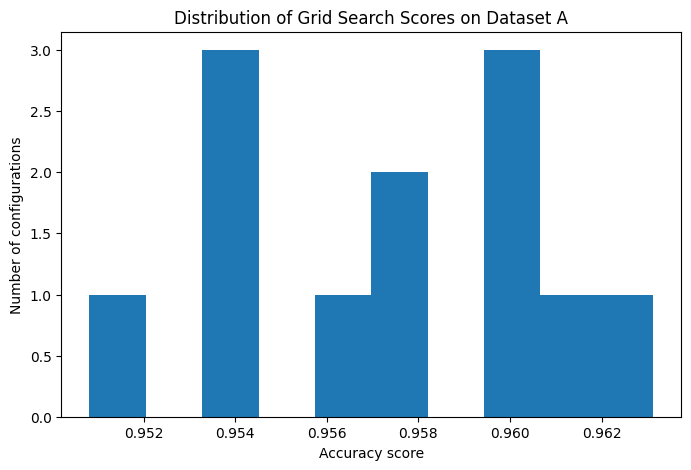

In [11]:
scores_A = [node.score for node in registry_A.all_trials()]

plt.figure(figsize=(8, 5))
plt.hist(scores_A, bins=10)
plt.title("Distribution of Grid Search Scores on Dataset A")
plt.xlabel("Accuracy score")
plt.ylabel("Number of configurations")
plt.show()

> **Observation:** The histogram shows that the stored grid search scores are concentrated in a narrow accuracy range, roughly between 0.95 and 0.963. This means most Random Forest configurations performed well on Dataset A, with only small differences between the best and worst stored trials.

# 4. BST Introspection

In this section, we inspect the behaviour of the Binary Search Tree directly using a small example registry. This makes it easier to understand the four traversal orders: inorder, preorder, postorder, and level-order.

The goal is to connect the implementation to the algorithmic concepts from the course, especially how traversal order changes the way tree nodes are visited.

In [12]:
small_registry = HyperparamRegistry()

small_trials = [
    (0.80, {"model": "A"}),
    (0.60, {"model": "B"}),
    (0.90, {"model": "C"}),
    (0.50, {"model": "D"}),
    (0.70, {"model": "E"}),
    (0.85, {"model": "F"}),
    (0.95, {"model": "G"}),
]

for score, params in small_trials:
    small_registry.add_trial(score, params)

print("Small registry summary:")
small_registry.summary()

Small registry summary:


{'count': 7,
 'best_score': 0.95,
 'worst_score': 0.5,
 'mean_score': 0.7571428571428571,
 'tree_height': 3,
 'is_balanced': True}

## 4.1 Traversal outputs

The same BST can be visited in different orders. In-order traversal returns the nodes sorted by score, while pre-order, post-order, and level-order show different structural views of the tree.

In [13]:
bst_small = small_registry._bst

def scores(nodes):
    return [node.score for node in nodes]

print("Inorder:", scores(bst_small.inorder()))
print("Preorder:", scores(bst_small.preorder()))
print("Postorder:", scores(bst_small.postorder()))
print("Level-order:", [[node.score for node in level] for level in bst_small.level_order()])

Inorder: [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]
Preorder: [0.8, 0.6, 0.5, 0.7, 0.9, 0.85, 0.95]
Postorder: [0.5, 0.7, 0.6, 0.85, 0.95, 0.9, 0.8]
Level-order: [[0.8], [0.6, 0.9], [0.5, 0.7, 0.85, 0.95]]


> **Observation:** The inorder traversal returns the scores in ascending order, which confirms the BST property. Preorder starts from the root and is useful for copying or serialising the tree. Postorder visits children before the parent, which is useful when deleting a tree. Level-order shows the tree level by level, making the tree structure easier to visualise.

## 4.2 Tree height and balance

The height of a BST affects the cost of operations such as search, insert, and delete. A balanced tree keeps the height close to `log₂(n)`, while an unbalanced tree can become closer to a linked list.

In [14]:
import math

n_small = len(small_registry.all_trials())
height_small = small_registry.summary()["tree_height"]
log_bound_small = math.ceil(math.log2(n_small + 1))

print("Number of nodes:", n_small)
print("Tree height:", height_small)
print("Approximate log2(n + 1):", log_bound_small)
print("Is balanced:", small_registry.summary()["is_balanced"])

Number of nodes: 7
Tree height: 3
Approximate log2(n + 1): 3
Is balanced: True


> **Observation:** The small BST has 7 nodes, height 3, and is balanced. This matches the expected logarithmic height because `ceil(log₂(7 + 1)) = 3`. A balanced tree keeps operations such as search, insert, and delete efficient compared to a degenerate tree.

# 5. Dataset B — Exploration (Banknote Authentication)

In this section, we load Dataset B, the Banknote Authentication dataset. This dataset is different from Dataset A because it has only 4 numeric features instead of 30, and the features come from image-based wavelet statistics rather than medical tumour measurements.

This difference makes the transfer analysis interesting: we can test whether Random Forest hyperparameter configurations that performed well on the high-dimensional medical dataset also perform well on the lower-dimensional banknote dataset.

In [15]:
banknote_path = PROJECT_ROOT / "data" / "banknote.csv"

df_banknote = pd.read_csv(banknote_path)

print("Dataset B loaded successfully.")
print("Shape:", df_banknote.shape)

df_banknote.head()

Dataset B loaded successfully.
Shape: (1372, 5)


,variance,skewness,curtosis,entropy,target
0,1.121806,1.149455,-0.975970,0.354561,0
1,1.447066,1.064453,-0.895036,-0.128767,0
2,1.207810,-0.777352,0.122218,0.618073,0
3,1.063742,1.295478,-1.255397,-1.144029,0
4,-0.036772,-1.087038,0.736730,0.096587,0


> **Observation:** Dataset B has 1372 samples and 5 columns. The four feature columns are numeric banknote image statistics, and the `target` column is already binary. Compared with Dataset A, this dataset has fewer features but more rows.

In [16]:
df_banknote.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   target    1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


> **Observation:** Dataset B contains no missing values. The four input features are numeric, and the `target` column is an integer binary label. This confirms that the dataset is ready for model evaluation.

In [17]:
class_counts_banknote = df_banknote["target"].value_counts().sort_index()

class_balance_banknote = pd.DataFrame({
    "target": class_counts_banknote.index,
    "count": class_counts_banknote.values,
    "meaning": ["Forged", "Genuine"]
})

class_balance_banknote

,target,count,meaning
0,0,762,Forged
1,1,610,Genuine


> **Observation:** Dataset B is slightly imbalanced, with 762 forged banknotes and 610 genuine banknotes. Both classes still have many samples, so cross-validation accuracy is acceptable for comparing configurations in this project.

In [18]:
X_banknote = df_banknote.drop(columns=["target"])
y_banknote = df_banknote["target"]

print("X_banknote shape:", X_banknote.shape)
print("y_banknote shape:", y_banknote.shape)

X_banknote shape: (1372, 4)
y_banknote shape: (1372,)


> **Observation:** The feature matrix for Dataset B has shape `(1372, 4)`, and the target vector has shape `(1372,)`. This confirms that Dataset B is ready to be used for re-evaluating the same Random Forest configurations from Dataset A.

# 6. Phase 2 — BST Rebuild

In Phase 2, we re-evaluate every configuration from Dataset A on Dataset B. The goal is to see how the same Random Forest hyperparameters perform on a different dataset.

We compare three rebuild strategies:

- `rebuild_naive`: re-inserts trials in sorted order, which can create a degenerate BST
- `rebuild_shuffled`: shuffles trials before insertion to reduce the risk of degeneration
- `rebuild_balanced`: builds a balanced BST using divide and conquer

This section benchmarks the three strategies and compares the resulting tree structures.

In [19]:
from bst_toolkit import rebuild_naive, rebuild_shuffled, rebuild_balanced

## 6.1 Evaluation function for Dataset B

To rebuild the BST on Dataset B, we use the same Random Forest evaluation logic as before. The only difference is that the dataset passed to the function is now the Banknote dataset instead of the Breast Cancer dataset.

In [20]:
def evaluate_random_forest_banknote(params, dataset):
    X, y = dataset

    model = RandomForestClassifier(
        **params,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    return round(float(np.mean(scores)), 6)

## 6.2 Benchmarking rebuild strategies

We now benchmark the three rebuild strategies. Each strategy re-evaluates the configurations from Dataset A on Dataset B, then stores the new scores in a new BST-backed registry.

The benchmark results will show the average execution time in milliseconds for each rebuild method.

In [21]:
benchmark_results = []

rebuild_methods = [
    ("naive", rebuild_naive),
    ("shuffled", rebuild_shuffled),
    ("balanced", rebuild_balanced),
]

for name, rebuild_fn in rebuild_methods:
    mean_time_ms = benchmark(
        rebuild_fn,
        registry_A,
        evaluate_random_forest_banknote,
        (X_banknote, y_banknote),
        repeats=3
    )

    rebuilt_registry = rebuild_fn(
        registry_A,
        evaluate_random_forest_banknote,
        (X_banknote, y_banknote)
    )

    benchmark_results.append({
        "strategy": name,
        "mean_time_ms": mean_time_ms,
        "tree_height": rebuilt_registry.summary()["tree_height"],
        "is_balanced": rebuilt_registry.summary()["is_balanced"],
        "best_score": rebuilt_registry.summary()["best_score"],
        "stored_trials": rebuilt_registry.summary()["count"],
    })

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df

,strategy,mean_time_ms,tree_height,is_balanced,best_score,stored_trials
0,naive,5567.524834,5,False,0.995628,7
1,shuffled,5651.467333,4,False,0.995628,7
2,balanced,5630.185403,4,True,0.995628,12


> **Observation:** The naive rebuild produced an unbalanced tree because it reinserts trials in sorted order, which can push the BST toward a degenerate shape. The shuffled and balanced strategies produced balanced trees. The balanced strategy also preserved more stored trials in this run, while the naive and shuffled versions stored fewer unique scores because duplicate rounded scores were ignored by the BST.

In [22]:
registry_B = rebuild_balanced(
    registry_A,
    evaluate_random_forest_banknote,
    (X_banknote, y_banknote)
)

summary_B = pd.DataFrame([registry_B.summary()])
summary_B

,count,best_score,worst_score,mean_score,tree_height,is_balanced
0,12,0.995628,0.9621,0.986031,4,True


> **Observation:** The balanced rebuild produced a balanced tree with height 4 and 12 stored trials. The best score on Dataset B is about 0.9956, which is higher than the best score on Dataset A. This suggests that the Banknote dataset may be easier for the Random Forest model under the tested configurations.

# 7. Transfer Analysis

In this section, we compare the rankings of the same hyperparameter configurations between Dataset A and Dataset B. The goal is to identify which configurations improved, degraded, or stayed stable when transferred from the Breast Cancer dataset to the Banknote dataset.

The transfer analysis uses `analyse_transfer()` from Package 2. It compares the rank of each configuration in `registry_A` and `registry_B`, then computes:

`drift = rank_A - rank_B`

A positive drift means the configuration improved on Dataset B, while a negative drift means it performed worse in the ranking.

In [23]:
transfer_report = analyse_transfer(registry_A, registry_B)

transfer_df = pd.DataFrame(transfer_report)
transfer_df

,params,score_A,score_B,rank_A,rank_B,drift,transfer
0,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.954339,0.995628,9,1,8,good
1,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.954308,0.993441,11,6,5,good
2,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",0.957848,0.994898,7,4,3,good
3,"{'n_estimators': 50, 'max_depth': 10, 'min_sam...",0.959587,0.993441,5,5,0,stable
4,"{'n_estimators': 50, 'max_depth': 3, 'min_samp...",0.950815,0.962100,12,12,0,stable
5,"{'n_estimators': 50, 'max_depth': 10, 'min_sam...",0.963127,0.994898,1,2,-1,poor
6,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.961357,0.994898,2,3,-1,poor
7,"{'n_estimators': 50, 'max_depth': 3, 'min_samp...",0.954324,0.962100,10,11,-1,poor
8,"{'n_estimators': 100, 'max_depth': 5, 'min_sam...",0.957864,0.985423,6,8,-2,poor
9,"{'n_estimators': 50, 'max_depth': 5, 'min_samp...",0.956078,0.984695,8,10,-2,poor


> **Observation:** The transfer report shows that some configurations improved when moving from Dataset A to Dataset B, while others dropped in ranking. The strongest improver moved from rank 9 on Dataset A to rank 1 on Dataset B, giving a drift of +8. This means that a configuration that was not among the best on the Breast Cancer dataset became the best on the Banknote dataset.

In [24]:
top_improvers = transfer_df.sort_values("drift", ascending=False).head(3)
top_decliners = transfer_df.sort_values("drift", ascending=True).head(3)

display(top_improvers)
display(top_decliners)

,params,score_A,score_B,rank_A,rank_B,drift,transfer
0,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.954339,0.995628,9,1,8,good
1,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.954308,0.993441,11,6,5,good
2,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",0.957848,0.994898,7,4,3,good


,params,score_A,score_B,rank_A,rank_B,drift,transfer
11,"{'n_estimators': 50, 'max_depth': 5, 'min_samp...",0.959618,0.984695,3,9,-6,poor
10,"{'n_estimators': 200, 'max_depth': 5, 'min_sam...",0.959603,0.986150,4,7,-3,poor
8,"{'n_estimators': 100, 'max_depth': 5, 'min_sam...",0.957864,0.985423,6,8,-2,poor


> **Observation:** The top improvers are configurations that were not highly ranked on Dataset A but became much stronger on Dataset B. The top decliners show the opposite: they performed well on Dataset A but dropped in ranking on Dataset B. This confirms that a strong configuration on one dataset does not always transfer perfectly to another dataset.

# 8. Conclusion

This project built a BST-backed hyperparameter optimisation tool and used it to compare model configurations across two datasets. In Phase 1, Random Forest configurations were evaluated on the Breast Cancer Wisconsin dataset and stored in a Binary Search Tree by accuracy score. In Phase 2, the same configurations were re-evaluated on the Banknote Authentication dataset, and the BST was rebuilt using different strategies.

The results showed that several configurations performed well on both datasets, but the transfer analysis also showed ranking changes. This means that hyperparameters can generalise across datasets, but their relative performance still depends on the dataset structure.

## 8.1 Course concepts used

| Course concept | Where it was used |
|---|---|
| Exhaustive search | `grid_search()` generated every hyperparameter combination |
| Binary Search Tree | Trial scores were stored as BST keys |
| In-order traversal | Used to retrieve sorted trial results and rankings |
| Reverse in-order traversal | Used to retrieve top-k configurations |
| Range query with pruning | Used to find trials within a score interval |
| Divide and conquer | Used by `rebuild_balanced()` to create a balanced BST |
| Hash tables | Used in `analyse_transfer()` to map configurations to ranks |
| Benchmarking | Used to compare rebuild strategies |

## 8.2 Personal reflection

The most important part of this project was understanding how a data structure can support a real machine learning workflow. Instead of storing grid search results only in a list or DataFrame, the project used a BST to organise trials by score and retrieve useful information such as the best trial, top-k trials, and score ranges.

If I were to improve the project, I would add more models and compare how different algorithms transfer between datasets. I would also keep duplicate scores more explicitly, because different hyperparameter configurations can sometimes produce the same rounded accuracy.

## 8.3 Open question

One open question is whether the same transfer behaviour would appear with other model types, such as Support Vector Machines or Gradient Boosting. Testing multiple models would show whether the observed transfer patterns are specific to Random Forests or more general.